Resized Dataset for Skin Lesion Segmentation-new \
Training image size:  6503

## Modules

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt

import keras
from keras.models import Model, Sequential
from keras.layers import Activation, Dense, BatchNormalization, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


2026-02-19 15:09:56.847291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771513797.165254      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771513797.261523      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771513798.042443      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771513798.042493      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771513798.042497      24 computation_placer.cc:177] computation placer alr

## DataSet

In [2]:
path = "/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new"

train_img_path = os.path.join(path, "train/input/img")
train_mask_path = os.path.join(path, "train/ground truth/img")

test_img_path = os.path.join(path, "test/input/img")
test_mask_path = os.path.join(path, "test/ground truth/img")

In [3]:
train_img_path

'/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/train/input/img'

In [4]:
print(os.listdir(train_img_path)[:3])
print("Training image size: ", len(os.listdir(train_img_path)))

['ISIC_7151.jpg', 'ISIC_3944.jpg', 'ISIC_1756.jpg']
Training image size:  6503


In [5]:
#  test extracting the image name
files = os.listdir(train_img_path)
imgName = files[0]
imgName

'ISIC_7151.jpg'

In [6]:
print(os.listdir(train_img_path)[:5])
print(os.listdir(train_mask_path)[:5])

['ISIC_7151.jpg', 'ISIC_3944.jpg', 'ISIC_1756.jpg', 'ISIC_4752.jpg', 'ISIC_1875.jpg']
['ISIC_7151.jpg', 'ISIC_3944.jpg', 'ISIC_1756.jpg', 'ISIC_4752.jpg', 'ISIC_1875.jpg']


## Plot a sample

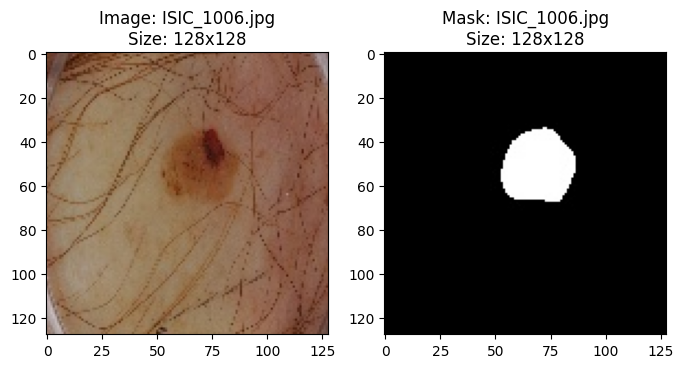

In [7]:
# list of images names ans coressbonding masks
files = sorted(os.listdir(train_img_path))
masks = sorted(os.listdir(train_mask_path))

# sample of image and mask
img_name = files[9]
mask_name = img_name.replace("X_", "Y_")

img = Image.open(os.path.join(train_img_path, img_name))
mask = Image.open(os.path.join(train_mask_path, mask_name))


# Get dimensions
width, height = img.size
    
# plot the sample image and its mask
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Image: {img_name}\nSize: {width}x{height}")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask: {mask_name}\nSize: {mask.size[0]}x{mask.size[1]}")

plt.show()

## Shape and Normalization

check the shape of a random input image

In [8]:
import cv2
img = cv2.imread((os.path.join(train_img_path,'ISIC_2338.jpg')))
img.shape


(128, 128, 3)

**Since the masks are black and white masks, we need to normalize it too**

In [9]:
X_train = np.array([np.array(Image.open(os.path.join(train_img_path, fname))) for fname in files])

Y_train = np.array([np.array(Image.open(os.path.join(train_img_path, fname))) for fname in masks])

In [10]:
X_train = X_train.astype('float32') / 255.0

# converting Binary Masks (0 and 255) to (0 and 1)
Y_train = (Y_train > 127).astype('uint8')

## Train_Test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size = 0.2, random_state = 42)

In [12]:
print("size of training images:", len(x_train))
print("size of testing images:", len(x_test))

size of training images: 5202
size of testing images: 1301


## Model Architecture

* The architecture we are implementing is suggested in [this](https://arxiv.org/pdf/1511.00561.pdf) paper.

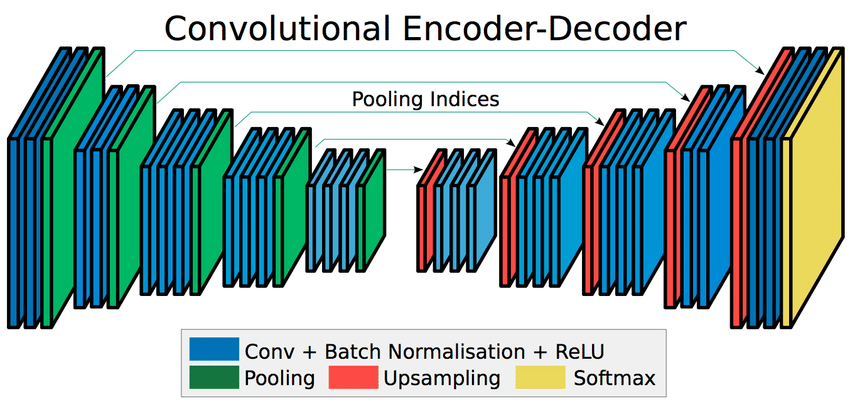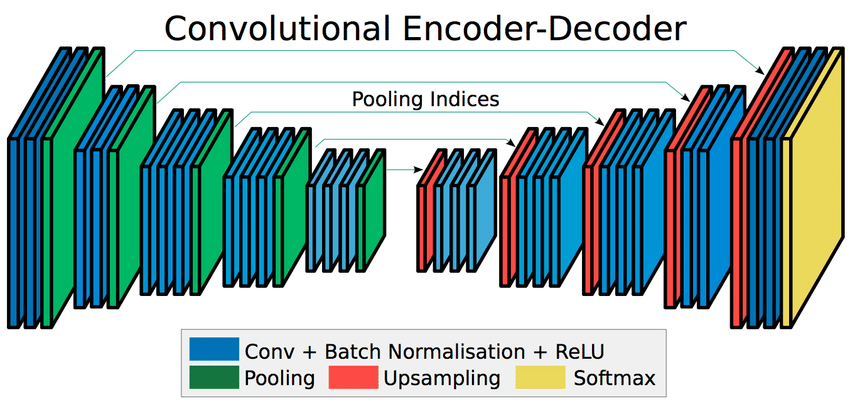

In [16]:
segnet = Sequential([

     # Encoding layer
     Input(shape= (128, 128, 3)),
     Conv2D(64, (3, 3), padding='same', activation= 'relu', strides= (1,1)),
     BatchNormalization(),
     Conv2D(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(name='bn3'),
     Conv2D(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),

     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2D(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     MaxPooling2D(),
     Dense(1024, activation = 'relu'),
     Dense(1024, activation = 'relu'),

     # Decoding Layer
     UpSampling2D(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(512, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(256, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(128, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Conv2DTranspose(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),

     UpSampling2D(),
     Conv2DTranspose(64, (3, 3), padding='same', activation= 'relu'),
     BatchNormalization(),
     Activation('relu'),
     Conv2DTranspose(3, (3, 3), padding='same', activation= 'sigmoid'),
     BatchNormalization(),
])


I0000 00:00:1771513845.766485      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Callbacks and Early stopping

**callbacks saves the best version of your model automatically based on the highest validation accuracy.**

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras", 
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

In [18]:
early_stopping = EarlyStopping(monitor='val_loss',patience=15, restore_best_weights=True, verbose=1)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.2,min_lr=1e-6)

callbacks_list = [early_stopping, reduce_lr, checkpoint]

## Compile and Train

In [19]:
segnet.compile(optimizer= Adam(learning_rate=0.001),
               loss= ["binary_crossentropy"], metrics=['accuracy'])
segnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 64, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 33,394,831 (127.39 MB)

 Trainable params: 33,378,953 (127.33 MB)

 Non-trainable params: 15,878 (62.02 KB)

In [20]:
segnet.fit(x_train, y_train, epochs= 10, batch_size= 32, validation_data= (x_test, y_test), verbose=1, callbacks= callbacks_list)

Epoch 1/10


I0000 00:00:1771513865.210410      70 service.cc:152] XLA service 0x7e84a80035a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771513865.210447      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771513868.085393      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771513888.966167      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.3111 - loss: 4.1087
Epoch 1: val_accuracy improved from -inf to 0.68190, saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 379ms/step - accuracy: 0.3113 - loss: 4.0994 - val_accuracy: 0.6819 - val_loss: 3.5955 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4483 - loss: 1.1679
Epoch 2: val_accuracy improved from 0.68190 to 0.83318, saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.4484 - loss: 1.1675 - val_accuracy: 0.8332 - val_loss: 0.5758 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5376 - loss: 0.8542
Epoch 3: val_accuracy improved from 0.83318 to 0.86646, saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.5376 - loss: 0.8538 - val_accuracy: 0.8665 - val_loss: 0.7338 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/s

In [21]:
segnet.evaluate(x_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9882 - loss: 0.3787


[0.3794595003128052, 0.9893041849136353]

## Model Validation

In [22]:
print(test_img_path)

/kaggle/input/datasets/apurboshahidshawon/resized-dataset-for-skin-lesion-segmentation-new/Resized_segmentation_dataset_new/test/input/img


In [23]:
# names and masks of the testing data
test_files = sorted(os.listdir(test_img_path))
test_masks = sorted(os.listdir(test_mask_path))

In [24]:
test_images = np.array([np.array(Image.open(os.path.join(test_img_path, fname))) for fname in test_files])
test_masks = np.array([np.array(Image.open(os.path.join(test_img_path, fname))) for fname in test_masks])

In [25]:
# Normalizing
test_images = test_images.astype('float32') / 255.0
test_masks = (test_masks > 127).astype('uint8')

In [26]:
predicted_masks = segnet.predict(test_images)


# Function to plot images and masks
for i in range(3):
    t_img = test_images[i]
    ground_truth_mask = test_masks[i]
    predicted_mask = predicted_masks[i]

# Crop input image using predicted mask
# overlay = input_image.copy()
# overlay[predicted_mask[:,:,0] < 0.5] = 0  # Set pixels outside mask to zero

    # Create figure and subplots for input, ground truth, predicted mask, and overlay
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    # Plot input image
    axs[0].imshow(t_img)
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    # Plot ground truth mask
    axs[1].imshow(ground_truth_mask[:, :, 0], cmap='gray')
    axs[1].set_title('Ground Truth Mask')
    axs[1].axis('off')

    # Plot predicted mask
    axs[2].imshow(predicted_mask[:, :, 0], cmap='gray')
    axs[2].set_title('Predicted Mask')
    axs[2].axis('off')

    # Plot overlay (cropped input image using predicted mask)
    # axs[3].imshow(overlay)
    # axs[3].set_title('Overlay: Input Image + Predicted Mask')
   # axs[3].axis('off')

    plt.tight_layout()


#   pdf.savefig(fig)
    plt.close(fig)

51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step


## Save the model

In [27]:
# Save the entire model to a single file
segnet.save("my_segmentation_model.keras")